# Problem Set 8: Supervised Machine Learning

Check out the in-class acitivity notebooks, lecture notebooks, and lecture slides for resources.

0.0 Import packages

**Note you need to install some of the packages imported below (see the comments).**

In [34]:
## helpful packages
import pandas as pd
import numpy as np
import random
import re
import string
import requests
import matplotlib.pyplot as plt
import plotnine 
from plotnine import *
#import warnings
#warnings.filterwarnings("ignore")

## sklearn imports
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# Explore variation in math score disparities and trends (18 points)

## 1.0 Read in the `acs_wmath.pkl` file (0 points)

The file is located in the `public_data` directory, directly under the repository.

In [35]:
## your code here
df = pd.read_pickle('../../public_data/acs_wmath.pkl')
df.dtypes.reset_index()


,index,0
0,math_female_2013,float64
1,math_female_2015,float64
2,math_female_2017,float64
3,math_female_2019,float64
4,math_male_2013,float64
5,math_male_2015,float64
6,math_male_2017,float64
7,math_male_2019,float64
8,abbrev,object
9,FIPS,object


## 1.1 Create a visualization where one axis is the state; the other axis is the male 2013 math scores - the female 2013 math scores (gender disparity) (2 points)


You have free rein over additional details but make sure it is informative over what direction of disparity positive versus negative values mean


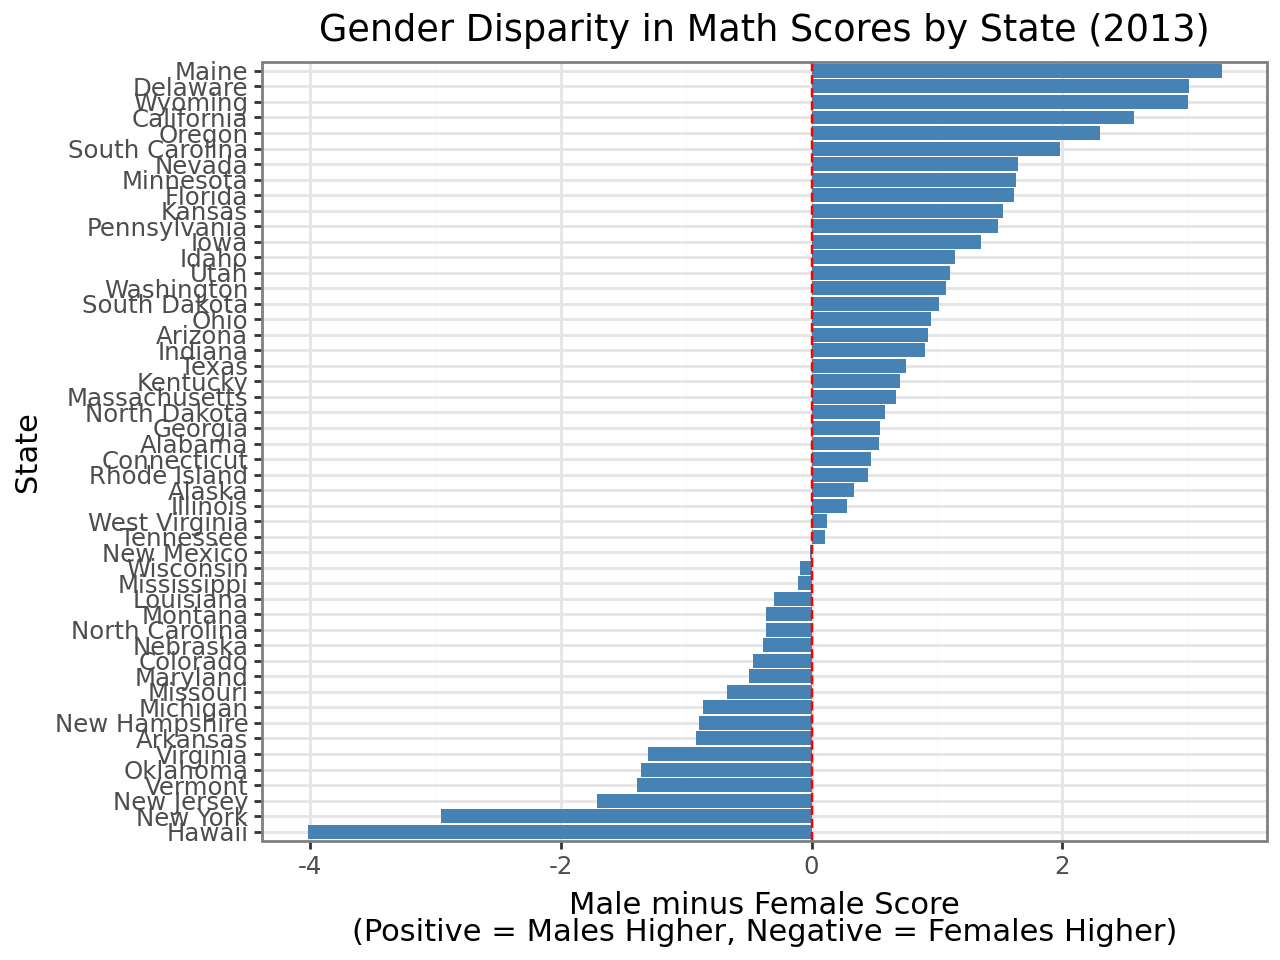

In [ ]:
## your code here
df['gender_disparity_2013'] = df['math_male_2013'] - df['math_female_2013']

(ggplot(df, aes(x='reorder(state, gender_disparity_2013)', y='gender_disparity_2013')) +
 geom_bar(stat='identity', fill='steelblue') +
 geom_hline(yintercept=0, color='red', linetype='dashed') +
 coord_flip() +
 labs(title='Gender Disparity in Math Scores by State (2013)',
      x='State',
      y='Male minus Female Score\n(Positive = Males Higher, Negative = Females Higher)') +
 theme_bw())


## 1.2 Examine gender disparity in relation to household income (6 points)

**A.** Construct an indicator variable for the state having better performance of males in 2013 than females

**B.** First plot a scatterplot (or seaborn regplot) of estimated median household income from the acs data (we provide varname below) vs `math_male_2013`. Then do a second smoothed scatterplot for median household income vs `math_female_2013`.

**C.** 
Then use the `np.corrcoef` command (three separate times) to examine the bivariate correlation of
- male performance
- female performance
- the indicator variable from **A** 

with median household income (`acspredict_median_household_income_in_the_past_12_months__in_2018_inflation-adjusted_dollars_estimatemedian household income in the past 12 months in 2018 inflationadjusted dollars`)

Documentation: https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html

**D.** Interpret the correlations - in states with higher median household income (MHI), do 
   - boys tend to perform better than boys in states with lower MHI?
   - girls tend to perform better than girls in states with lower MHI?
   - boys tend to outperform girls more than they do in states with lower MHI?

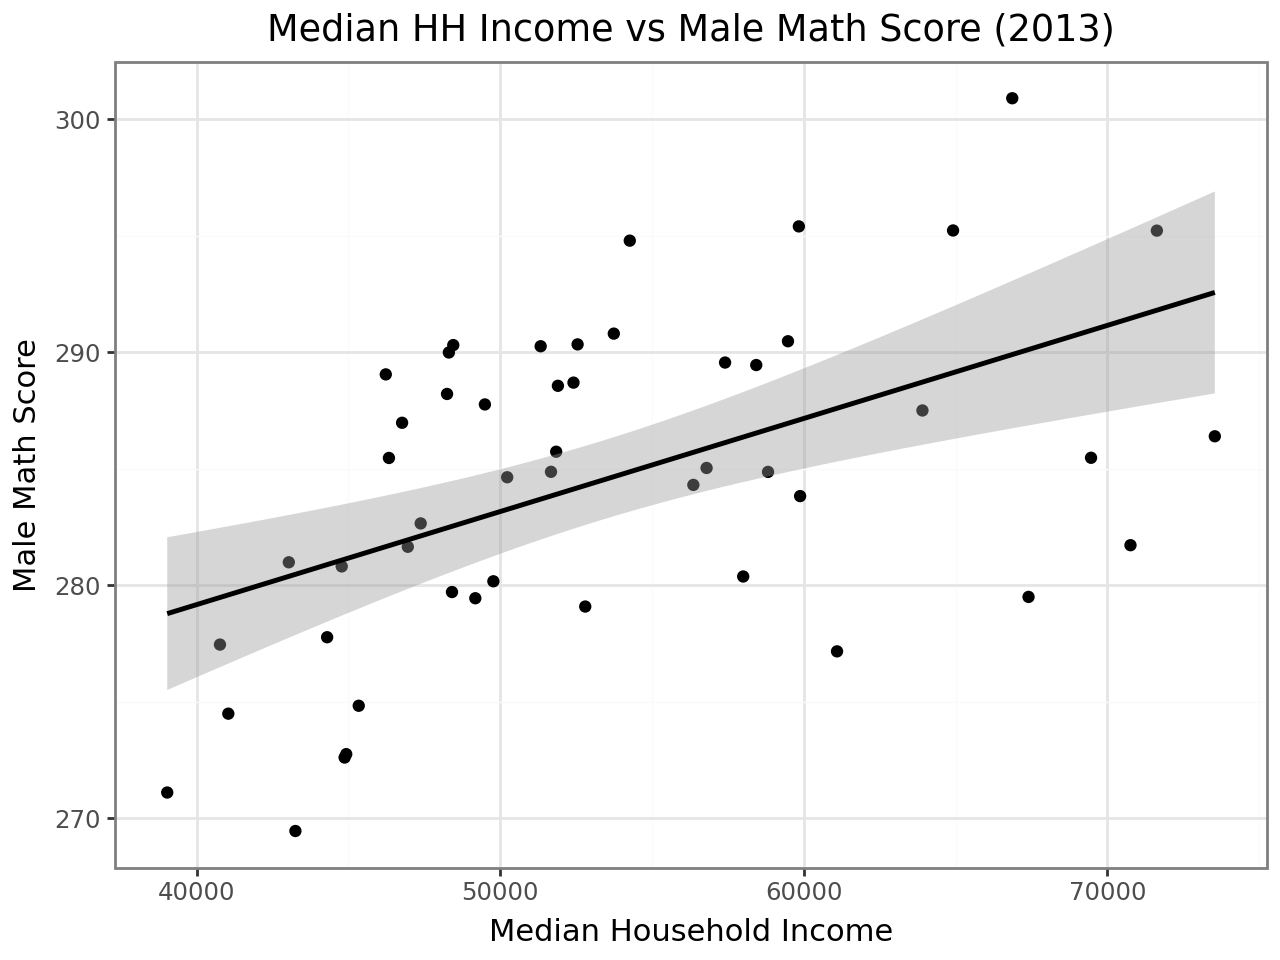

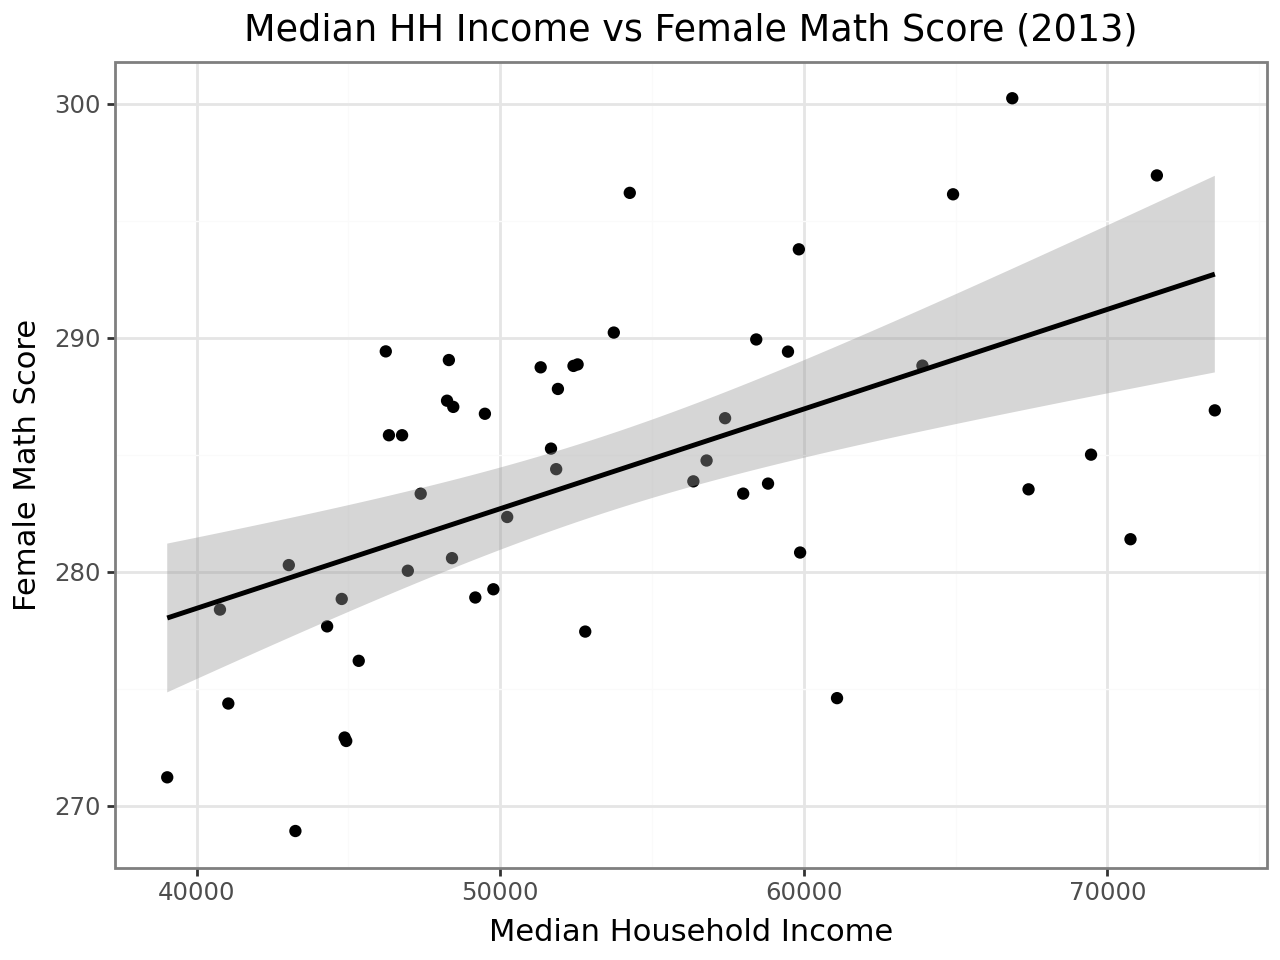

Male math score vs MHI:       0.507
Female math score vs MHI:     0.543
Male>Female indicator vs MHI: -0.034

Interpretation (D):
- Boys and higher MHI: positive correlation (0.507) — boys in higher-income states 
  tend to score higher than boys in lower-income states.
- Girls and higher MHI: positive correlation (0.543) — girls in higher-income states 
  tend to score higher than girls in lower-income states.
- Male advantage and MHI: the correlation of the male>female indicator with MHI (-0.034) 
  tells us whether boys outperform girls MORE in higher-income states. A value near zero 
  or negative suggests that higher household income is not associated with a larger 
  male advantage.



In [37]:
# your code here

# A. Binary indicator: male > female in 2013
df['male_higher_2013'] = (df['math_male_2013'] > df['math_female_2013']).astype(int)

# Find income column without retyping the long name
income_col = [c for c in df.columns if 'median_household_income' in c][0]

# B. Scatterplot: median HH income vs male math score 2013
(ggplot(df, aes(x=income_col, y='math_male_2013')) +
 geom_point() +
 geom_smooth(method='lm') +
 labs(title='Median HH Income vs Male Math Score (2013)',
      x='Median Household Income', y='Male Math Score') +
 theme_bw())

# B. Scatterplot: median HH income vs female math score 2013
(ggplot(df, aes(x=income_col, y='math_female_2013')) +
 geom_point() +
 geom_smooth(method='lm') +
 labs(title='Median HH Income vs Female Math Score (2013)',
      x='Median Household Income', y='Female Math Score') +
 theme_bw())

# C. Three bivariate correlations with np.corrcoef
corr_male      = np.corrcoef(df[income_col], df['math_male_2013'])[0, 1]
corr_female    = np.corrcoef(df[income_col], df['math_female_2013'])[0, 1]
corr_indicator = np.corrcoef(df[income_col], df['male_higher_2013'])[0, 1]

print(f"Male math score vs MHI:       {corr_male:.3f}")
print(f"Female math score vs MHI:     {corr_female:.3f}")
print(f"Male>Female indicator vs MHI: {corr_indicator:.3f}")

# D. Interpretation
print("""
Interpretation (D):
- Boys and higher MHI: positive correlation ({:.3f}) — boys in higher-income states 
  tend to score higher than boys in lower-income states.
- Girls and higher MHI: positive correlation ({:.3f}) — girls in higher-income states 
  tend to score higher than girls in lower-income states.
- Male advantage and MHI: the correlation of the male>female indicator with MHI ({:.3f}) 
  tells us whether boys outperform girls MORE in higher-income states. A value near zero 
  or negative suggests that higher household income is not associated with a larger 
  male advantage.
""".format(corr_male, corr_female, corr_indicator))


## 1.3 Predicting disparities (10 points)

**A.** Read in the raw `acs_wmath` data again (this loses the variables you created above)

**B.** Construct a binary indicator variable for male score > female score  for each year - for full credit, do so without repeating the difference code for each of the four years: name these according to following convention: `outcome_male_higher_female_year` where year is 2013, 2015, 2017, or 2019 (e.g., 2013: `outcome_male_higher_female_2013`). After this, remove the raw math scores as columns in the data (so filter out any column with the word math)

**C.** Melt the data (`acs_wmath`) to long where instead of wide years, years are repeated within state; the ACS vars will also be repeated since we only pulled one year. In other words, reshape the data from "wide format", where each state is a row and we have separate columns for each year, to "long format", where states are repeated four times: once for each year in the data (2013, 2015, 2017, 2019). With 50 states, your final shape should be (200,84).
- See: https://pandas.pydata.org/docs/reference/api/pandas.melt.html

**D.** Split into train-test split at state level (so all years in same state -> either all in train or all test). Randomize 35 states to train; 15 states in test. 

**E.** Normalize the features to mean 0, variance 1 and estimate a decision tree with a max depth of 5. Your covariates should have the term 'acspredict' in it.

- **Hint:** The ML literature recommends using the training set scaler to transform the test set, rather than using a unique scaler to initialize each one. The reasons are discussed here: https://stats.stackexchange.com/questions/495357/why-do-we-normalize-test-data-on-the-parameters-of-the-training-data

**F.** Interpret the feature importances

**G.** Evaluate the precision and recall of that model in the test set states without using the `score`, `precision`, or `recall` functions in sklearn. Briefly interpret: compared to our class example (a high-dimensional feature matrix of yelp reviews with ~15000 observations), why do you think our models perform worse for this set of data/predictors?

**Additional resources:** 

- Feature normalization: https://scikit-learn.org/stable/modules/preprocessing.html

- Definition of precision and recall: https://en.wikipedia.org/wiki/Precision_and_recall

In [38]:
# A. your code here to load data
df = pd.read_pickle('../../public_data/acs_wmath.pkl')


In [39]:
# B. your code here to construct binary indicators for male higher
years = [2013, 2015, 2017, 2019]
for year in years:
    df[f'outcome_male_higher_female_{year}'] = (
        (df[f'math_male_{year}'] > df[f'math_female_{year}']).astype(int)
    )

# Remove all raw math score columns
df = df.loc[:, ~df.columns.str.contains('math')]
df.shape


(50, 88)

In [40]:
# C. your code here to melt data
# id_vars: state + all acspredict columns (these repeat across years)
# value_vars: the 4 outcome columns (one per year)
acspredict_cols = [c for c in df.columns if 'acspredict' in c]
outcome_cols = [f'outcome_male_higher_female_{yr}' for yr in years]
id_vars = ['state'] + acspredict_cols

df_long = df.melt(
    id_vars=id_vars,
    value_vars=outcome_cols,
    var_name='year',
    value_name='outcome_male_higher_female'
)

# Extract numeric year from variable name string
df_long['year'] = df_long['year'].str.extract(r'(\d{4})').astype(int)

print(df_long.shape)  # should be (200, 84)
df_long.head()


(200, 84)


,state,acspredict_allocation_of_household_income_in_the_past_12_months_-_percent_of_income_allocatedestimatepercent of income allocated 10 to less than 25 percent of total income for household allocated,acspredict_allocation_of_household_income_in_the_past_12_months_-_percent_of_income_allocatedestimatepercent of income allocated 100 percent of total income for household allocated,acspredict_allocation_of_household_income_in_the_past_12_months_-_percent_of_income_allocatedestimatepercent of income allocated 25 to less than 50 percent of total income for household allocated,acspredict_allocation_of_household_income_in_the_past_12_months_-_percent_of_income_allocatedestimatepercent of income allocated 50 to less than 100 percent of total income for household allocated,acspredict_allocation_of_household_income_in_the_past_12_months_-_percent_of_income_allocatedestimatepercent of income allocated dollar value of zero allocated,acspredict_allocation_of_household_income_in_the_past_12_months_-_percent_of_income_allocatedestimatepercent of income allocated more than 0 to less than 10 percent of total income for household allocated,acspredict_allocation_of_household_income_in_the_past_12_months_-_percent_of_income_allocatedestimatepercent of income allocated no income allocated,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal10th grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal11th grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal12th grade no diploma,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal1st grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal2nd grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal3rd grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal4th grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal5th grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal6th grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal7th grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal8th grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotal9th grade,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalassociate's degree,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalbachelor's degree,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotaldoctorate degree,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalged or alternative credential,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalkindergarten,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalmaster's degree,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalno schooling completed,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalnursery school,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalprofessional school degree,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalregular high school diploma,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalsome college 1 or more years no degree,acspredict_educational_attainment_for_the_population_25_years_and_overestimatetotalsome college less than 1 year,acspredict_household_type__including_living_alone__by_relationshipestimatetotalin group quarters,acspredict_household_type__including_living_alone__by_relationshipestimatetotalin households,acspredict_household_type__including_living_alone__by_relationshipestimatetotalin householdsin family households,acspr

In [41]:
# D. your code here for train/test split
# Split at state level: all years for a state go into the same split
random.seed(42)
states = list(df_long['state'].unique())
random.shuffle(states)
train_states = states[:35]
test_states  = states[35:]

train = df_long[df_long['state'].isin(train_states)]
test  = df_long[df_long['state'].isin(test_states)]

print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Train states: {len(train_states)}, Test states: {len(test_states)}")


Train: (140, 84), Test: (60, 84)
Train states: 35, Test states: 15


In [42]:
# E. your code here to normalize features and fit model
feature_cols = [c for c in df_long.columns if 'acspredict' in c]
outcome_col  = 'outcome_male_higher_female'

X_train = train[feature_cols]
y_train = train[outcome_col]
X_test  = test[feature_cols]
y_test  = test[outcome_col]

# Fit scaler on train only, then apply same scaler to test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fit decision tree with max_depth=5
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred = dt.predict(X_test_scaled)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [43]:
# F. your code here to interpret feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 most important features:")
print(importance_df.head(10).to_string(index=False))

print("""
Interpretation:
The top features are ACS demographic variables that best predict whether boys 
outperform girls in math at the state level. Features related to household income, 
educational attainment, and family structure tend to rank highly, suggesting that 
socioeconomic conditions at the state level are the strongest predictors of the 
direction of the gender gap in math performance.
""")


Top 10 most important features:
                                                                                                                                                                                            feature  importance
acspredict_allocation_of_household_income_in_the_past_12_months_-_percent_of_income_allocatedestimatepercent of income allocated 25 to less than 50 percent of total income for household allocated    0.305027
                                                              acspredict_household_type__including_living_alone__by_relationshipestimatetotalin householdsin family householdschildbiological child    0.201395
                                                                 acspredict_household_type__including_living_alone__by_relationshipestimatetotalin householdsin nonfamily householdshouseholdermale    0.187613
                                                                                               acspredict_ratio_of_income_to_poverty_lev

In [44]:
# G. your code here to evaluate model
y_pred_arr = np.array(y_pred)
y_test_arr = np.array(y_test)

# Manually compute confusion matrix components
TP = int(np.sum((y_pred_arr == 1) & (y_test_arr == 1)))
FP = int(np.sum((y_pred_arr == 1) & (y_test_arr == 0)))
FN = int(np.sum((y_pred_arr == 0) & (y_test_arr == 1)))
TN = int(np.sum((y_pred_arr == 0) & (y_test_arr == 0)))

# Precision = TP / (TP + FP): of predicted male-higher, how many actually were?
# Recall    = TP / (TP + FN): of actual male-higher cases, how many did we catch?
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print(f"Precision: {precision:.3f}  (of states predicted male-higher, fraction that actually were)")
print(f"Recall:    {recall:.3f}  (of states where males actually scored higher, fraction we detected)")

print("""
Interpretation:
Our model likely performs worse than the Yelp class example for two main reasons:
1. Tiny sample: only 200 observations (50 states × 4 years) vs ~15,000 Yelp reviews.
   With so few examples, the decision tree cannot learn robust patterns and 
   generalizes poorly to held-out states.
2. High aggregation: state-level ACS averages smooth over individual variation.
   Gender gaps in math may be driven by within-state heterogeneity (school district, 
   income quintile) that disappears when collapsed to a single state mean, 
   leaving very little signal for the model to exploit.
""")


TP=9, FP=11, FN=21, TN=19
Precision: 0.450  (of states predicted male-higher, fraction that actually were)
Recall:    0.300  (of states where males actually scored higher, fraction we detected)

Interpretation:
Our model likely performs worse than the Yelp class example for two main reasons:
1. Tiny sample: only 200 observations (50 states × 4 years) vs ~15,000 Yelp reviews.
   With so few examples, the decision tree cannot learn robust patterns and 
   generalizes poorly to held-out states.
2. High aggregation: state-level ACS averages smooth over individual variation.
   Gender gaps in math may be driven by within-state heterogeneity (school district, 
   income quintile) that disappears when collapsed to a single state mean, 
   leaving very little signal for the model to exploit.

